In [2]:
import pandas as pd
import numpy as np
import string 

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv("Formspring.csv")
df.head()

,text,answer
0,Q: what&#039;s your favorite song? :D<br>A: I ...,No
1,Q: <3<br>A: </3 ? haha jk! <33,No
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,No
3,Q: (:<br>A: ;(,No
4,Q: ******************MEOWWW*******************...,No


In [4]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1] } columns ")

Dataset has 13147 rows and 2 columns 


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13147 entries, 0 to 13146
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    13147 non-null  object
 1   answer  13147 non-null  object
dtypes: object(2)
memory usage: 205.6+ KB


In [6]:
df.describe()

,text,answer
count,13147,13147
unique,13144,2
top,Q: Wait. Are you Cheyenne? I sent a request to...,No
freq,3,12295


In [7]:
df.isnull().sum()

text      0
answer    0
dtype: int64

In [8]:
df["answer"].value_counts()

answer
No     12295
Yes      852
Name: count, dtype: int64

In [9]:
formspring_text_features=df["text"].copy()
tfid_vectorizer=TfidfVectorizer(encoding="english")
formspring_features=tfid_vectorizer.fit_transform(formspring_text_features)

print("Text Features from the Dataset - Formsprong.csv:")
print('-'*63)
print(formspring_text_features)

Text Features from the Dataset - Formsprong.csv:
---------------------------------------------------------------
0        Q: what&#039;s your favorite song? :D<br>A: I ...
1                           Q: <3<br>A: </3 ? haha jk! <33
2        Q: &quot;hey angel  you duh sexy&quot;<br>A: R...
3                                           Q: (:<br>A: ;(
4        Q: ******************MEOWWW*******************...
                               ...                        
13142    Q: Youre at a party and your friend who drove ...
13143    Q: Youu2019re awesome :] Give yourself a compl...
13144    Q: Yu play with yurself ?<br>A: all the time. ...
13145    Q: yukk beer is disgusting. i can only drink i...
13146    Q: if i told u den it would make it all the le...
Name: text, Length: 13147, dtype: object


In [10]:
print("Features from the Dataset-Formspring.csv:")
print('-'*53)
print(formspring_features)

Features from the Dataset-Formspring.csv:
-----------------------------------------------------
  (0, 17947)	0.15984947496542218
  (0, 4)	0.21166783975854714
  (0, 18614)	0.16445580974678042
  (0, 6020)	0.5901629635353193
  (0, 15130)	0.3373860496444202
  (0, 2417)	0.06294444269439241
  (0, 9775)	0.19038717708585326
  (0, 16688)	0.26377533756496274
  (0, 10321)	0.30068023170403524
  (0, 15135)	0.43794630875263
  (0, 16619)	0.13666204960704684
  (0, 7574)	0.17265193864975523
  (1, 2417)	0.10517467075209344
  (1, 7324)	0.3741534117644444
  (1, 8965)	0.6831137869399058
  (1, 212)	0.6183066126040022
  (2, 2417)	0.05634780356239197
  (2, 7324)	0.20045437554062448
  (2, 13327)	0.5094343603709673
  (2, 7765)	0.2886547397744486
  (2, 1044)	0.4381590967996309
  (2, 18600)	0.0865259371250384
  (2, 5157)	0.42483910836891375
  (2, 14472)	0.3371973861965128
  (2, 13501)	0.2132496484348259
  :	:
  (13145, 5128)	0.22992749038686963
  (13145, 4804)	0.3182924140169115
  (13145, 17605)	0.267670631778288

In [11]:
saved_formspring_df=pd.DataFrame(formspring_text_features)
saved_formspring_df.to_csv("Formspring Text Features.csv")

**Label encoding**:sklearn requires all inputs to be numeric, we need to convert all categorical variables (string labels) into numeric by encoding 
the categories i.e 'No', 'yes' to 0,1 sklearn provides LabelEncoder library for encoding labels between 0 to n-1 discrete classes,where n is the number of class-labels

In [13]:
from sklearn.preprocessing import LabelEncoder

column=["answer"]
print("Column:",column)

Column: ['answer']


In [14]:
label_encoder=LabelEncoder()

for i in column:
    df[i]=label_encoder.fit_transform(df[i])

print("Dataset Data Types:")
print('-'*33)
print(df.dtypes)

Dataset Data Types:
---------------------------------
text      object
answer     int64
dtype: object


In [15]:
print("First 10 Elements from the 'Dataset - Formspring.csv':")
print('-' * 63)
df.head()

First 10 Elements from the 'Dataset - Formspring.csv':
---------------------------------------------------------------


,text,answer
0,Q: what&#039;s your favorite song? :D<br>A: I ...,0
1,Q: <3<br>A: </3 ? haha jk! <33,0
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,0
3,Q: (:<br>A: ;(,0
4,Q: ******************MEOWWW*******************...,0


In [16]:
print("Last 10 Elements from the 'Dataset - Formspring.csv':")
print('-' * 63)
df.tail()

Last 10 Elements from the 'Dataset - Formspring.csv':
---------------------------------------------------------------


,text,answer
13142,Q: Youre at a party and your friend who drove ...,0
13143,Q: Youu2019re awesome :] Give yourself a compl...,0
13144,Q: Yu play with yurself ?<br>A: all the time. ...,0
13145,Q: yukk beer is disgusting. i can only drink i...,0
13146,Q: if i told u den it would make it all the le...,0


In [17]:
formspring_features_train,formspring_features_test,formspring_labels_train,formspring_labels_test=train_test_split(
    formspring_features,
    df["answer"],
    test_size=0.3,
    random_state=4861
)

In [18]:
print("Features Train from the 'Dataset - Formspring.csv':")
print('-' * 53)
print(formspring_features_train)

Features Train from the 'Dataset - Formspring.csv':
-----------------------------------------------------
  (0, 2417)	0.03554805974627196
  (0, 16619)	0.07718029577394415
  (0, 18600)	0.054586496510325856
  (0, 9954)	0.10429408251589235
  (0, 10481)	0.10405181432957193
  (0, 9348)	0.12154826875015336
  (0, 4873)	0.08636409381158049
  (0, 12620)	0.4254544835107159
  (0, 8361)	0.11959751173117253
  (0, 2859)	0.12741497551261466
  (0, 8079)	0.11654039500223604
  (0, 2720)	0.10971778532157818
  (0, 15542)	0.16819394890336758
  (0, 16149)	0.26280618295286606
  (0, 13058)	0.26801765201244987
  (0, 12703)	0.6468133399762015
  (0, 1905)	0.34804670737560567
  (1, 2417)	0.04981611402851899
  (1, 18600)	0.076496077535172
  (1, 7044)	0.23073939557861475
  (1, 14338)	0.23073939557861475
  (1, 15567)	0.2641370614165871
  (1, 17611)	0.4186836846730796
  (1, 12013)	0.28504038186951564
  (1, 18526)	0.3199978896093582
  :	:
  (9201, 8261)	0.15428670154346316
  (9201, 16365)	0.10697073705480287
  (9201, 

In [19]:
print("Features Test from the 'Dataset - Formspring.csv':")
print('-' * 53)
print(formspring_features_test)

Features Test from the 'Dataset - Formspring.csv':
-----------------------------------------------------
  (0, 2417)	0.0871288068770038
  (0, 11539)	0.4348566941761628
  (0, 757)	0.543294262374109
  (0, 17272)	0.7128390919511511
  (1, 17947)	0.07632386129324027
  (1, 2417)	0.03005429273024719
  (1, 16619)	0.06525248406674125
  (1, 18600)	0.04615043850352481
  (1, 1149)	0.13369782864014165
  (1, 1030)	0.07126466246482528
  (1, 11716)	0.16632759683822806
  (1, 18021)	0.10472726260005898
  (1, 10053)	0.1095021665550937
  (1, 8720)	0.08034314350188487
  (1, 8434)	0.08303028290530447
  (1, 18166)	0.0998524702814988
  (1, 18621)	0.1610928410049845
  (1, 16341)	0.26282266309230107
  (1, 18273)	0.1627476236661054
  (1, 16329)	0.08283111522658117
  (1, 876)	0.22116415535751952
  (1, 12344)	0.11916159343785462
  (1, 15258)	0.19520386014948365
  (1, 3903)	0.1329171537679675
  (1, 1921)	0.2889582677005952
  :	:
  (3942, 11963)	0.2631816685639098
  (3942, 2076)	0.2631816685639098
  (3942, 12047)	0.

In [20]:
print("First 10 Elements from Formspring Labels Train:")
print('-' * 53)
formspring_labels_train.head(10)

First 10 Elements from Formspring Labels Train:
-----------------------------------------------------


5634     0
3350     0
8939     0
5109     0
1001     0
5754     0
12939    0
7619     0
5705     0
10248    0
Name: answer, dtype: int64

In [21]:
print("Last 10 Elements from Formspring Labels Test:")
print('-' * 53)
formspring_labels_test.tail(10)

Last 10 Elements from Formspring Labels Test:
-----------------------------------------------------


6376     0
5645     0
54       0
9025     0
11808    0
7440     0
9434     0
2928     0
7176     0
7887     0
Name: answer, dtype: int64

In [22]:
from sklearn.model_selection import GridSearchCV

from sklearn.svm import(SVR,SVC)
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import  DecisionTreeClassifier
from sklearn.linear_model import(Ridge,RidgeClassifier,SGDRegressor,SGDClassifier,LogisticRegression)
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

from matplotlib import style
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# Support Vector Classification

In [24]:
svc=SVC(kernel="sigmoid",gamma=1.0)

svc.fit(formspring_features_train,formspring_labels_train)

svc_prediction=svc.predict(formspring_features_test)
svc_accuracy_score = accuracy_score(formspring_labels_test, svc_prediction)
svc_precision_score = precision_score(formspring_labels_test, svc_prediction)
svc_recall_score = recall_score(formspring_labels_test, svc_prediction)
svc_f1_score = f1_score(formspring_labels_test, svc_prediction)

print("________Evaluation for: C-Support Vector Classification________")
print(f"Model Type:         {svc}")
print(f"Accuracy Score:     {svc_accuracy_score:%}")
print(f"Precision Score:    {svc_precision_score:%}")
print(f"Recall Score:       {svc_recall_score:%}")
print(f"F1-Score:           {svc_f1_score:%}")


________Evaluation for: C-Support Vector Classification________
Model Type:         SVC(gamma=1.0, kernel='sigmoid')
Accuracy Score:     95.082383%
Precision Score:    80.519481%
Recall Score:       25.726141%
F1-Score:           38.993711%


In [25]:
print("C-Support Vector Classification - Confusion Matrix:")
print(confusion_matrix(formspring_labels_test,svc_prediction))

C-Support Vector Classification - Confusion Matrix:
[[3689   15]
 [ 179   62]]


In [26]:
print("C-Support Vector Classification - Confusion Matrix:")
print(classification_report(formspring_labels_test,svc_prediction))

C-Support Vector Classification - Confusion Matrix:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3704
           1       0.81      0.26      0.39       241

    accuracy                           0.95      3945
   macro avg       0.88      0.63      0.68      3945
weighted avg       0.94      0.95      0.94      3945



# MultinomialNB

In [28]:
mnb = MultinomialNB(alpha=0.2)

mnb.fit(formspring_features_train, formspring_labels_train)

mnb_prediction = mnb.predict(formspring_features_test)
mnb_accuracy_score = accuracy_score(formspring_labels_test, mnb_prediction)
mnb_precision_score = precision_score(formspring_labels_test, mnb_prediction)
mnb_recall_score = recall_score(formspring_labels_test, mnb_prediction)
mnb_f1_score = f1_score(formspring_labels_test, mnb_prediction)

print("________Evaluation for:  Multinomial Naive Bayes Classifier________")
print(f"Model Type:         {mnb}")
print(f"Accuracy Score:     {mnb_accuracy_score:%}")
print(f"Precision Score:    {mnb_precision_score:%}")
print(f"Recall Score:       {mnb_recall_score:%}")
print(f"F1-Score:           {mnb_f1_score:%}")



________Evaluation for:  Multinomial Naive Bayes Classifier________
Model Type:         MultinomialNB(alpha=0.2)
Accuracy Score:     94.017744%
Precision Score:    53.623188%
Recall Score:       15.352697%
F1-Score:           23.870968%


In [29]:
print(" Multinomial Naive Bayes Classifier - Confusion Matrix:")
print(confusion_matrix(formspring_labels_test,mnb_prediction))

 Multinomial Naive Bayes Classifier - Confusion Matrix:
[[3672   32]
 [ 204   37]]


In [30]:
print("Multinomial Naive Bayes Classifier - Classification Report:")
print(classification_report(formspring_labels_test,mnb_prediction))

Multinomial Naive Bayes Classifier - Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3704
           1       0.54      0.15      0.24       241

    accuracy                           0.94      3945
   macro avg       0.74      0.57      0.60      3945
weighted avg       0.92      0.94      0.92      3945



# Decision Tree Classifier

In [32]:
dtc=DecisionTreeClassifier()

dtc.fit(formspring_features_train,formspring_labels_train)

dtc_prediction=dtc.predict(formspring_features_test)
dtc_accuracy_score=accuracy_score(formspring_labels_test,dtc_prediction)
dtc_precision_score = precision_score(formspring_labels_test, dtc_prediction)
dtc_recall_score = recall_score(formspring_labels_test, dtc_prediction)
dtc_f1_score = f1_score(formspring_labels_test, dtc_prediction)


print("________Evaluation for: Decision Tree Classifier________")
print(f"Model Type:         {dtc}")
print(f"Accuracy Score:     {dtc_accuracy_score:%}")
print(f"Precision Score:    {dtc_precision_score:%}")
print(f"Recall Score:       {dtc_recall_score:%}")
print(f"F1-Score:           {dtc_f1_score:%}")



________Evaluation for: Decision Tree Classifier________
Model Type:         DecisionTreeClassifier()
Accuracy Score:     92.826362%
Precision Score:    39.393939%
Recall Score:       32.365145%
F1-Score:           35.535308%


In [33]:
print("Decision Tree Classifie: Confusion Matrix")
print(confusion_matrix(formspring_labels_test,dtc_prediction))

Decision Tree Classifie: Confusion Matrix
[[3584  120]
 [ 163   78]]


In [34]:
print("Decision Tree Classifie: Classification Report")
print(classification_report(formspring_labels_test,dtc_prediction))

Decision Tree Classifie: Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      3704
           1       0.39      0.32      0.36       241

    accuracy                           0.93      3945
   macro avg       0.68      0.65      0.66      3945
weighted avg       0.92      0.93      0.92      3945



# Visualization of all model scores

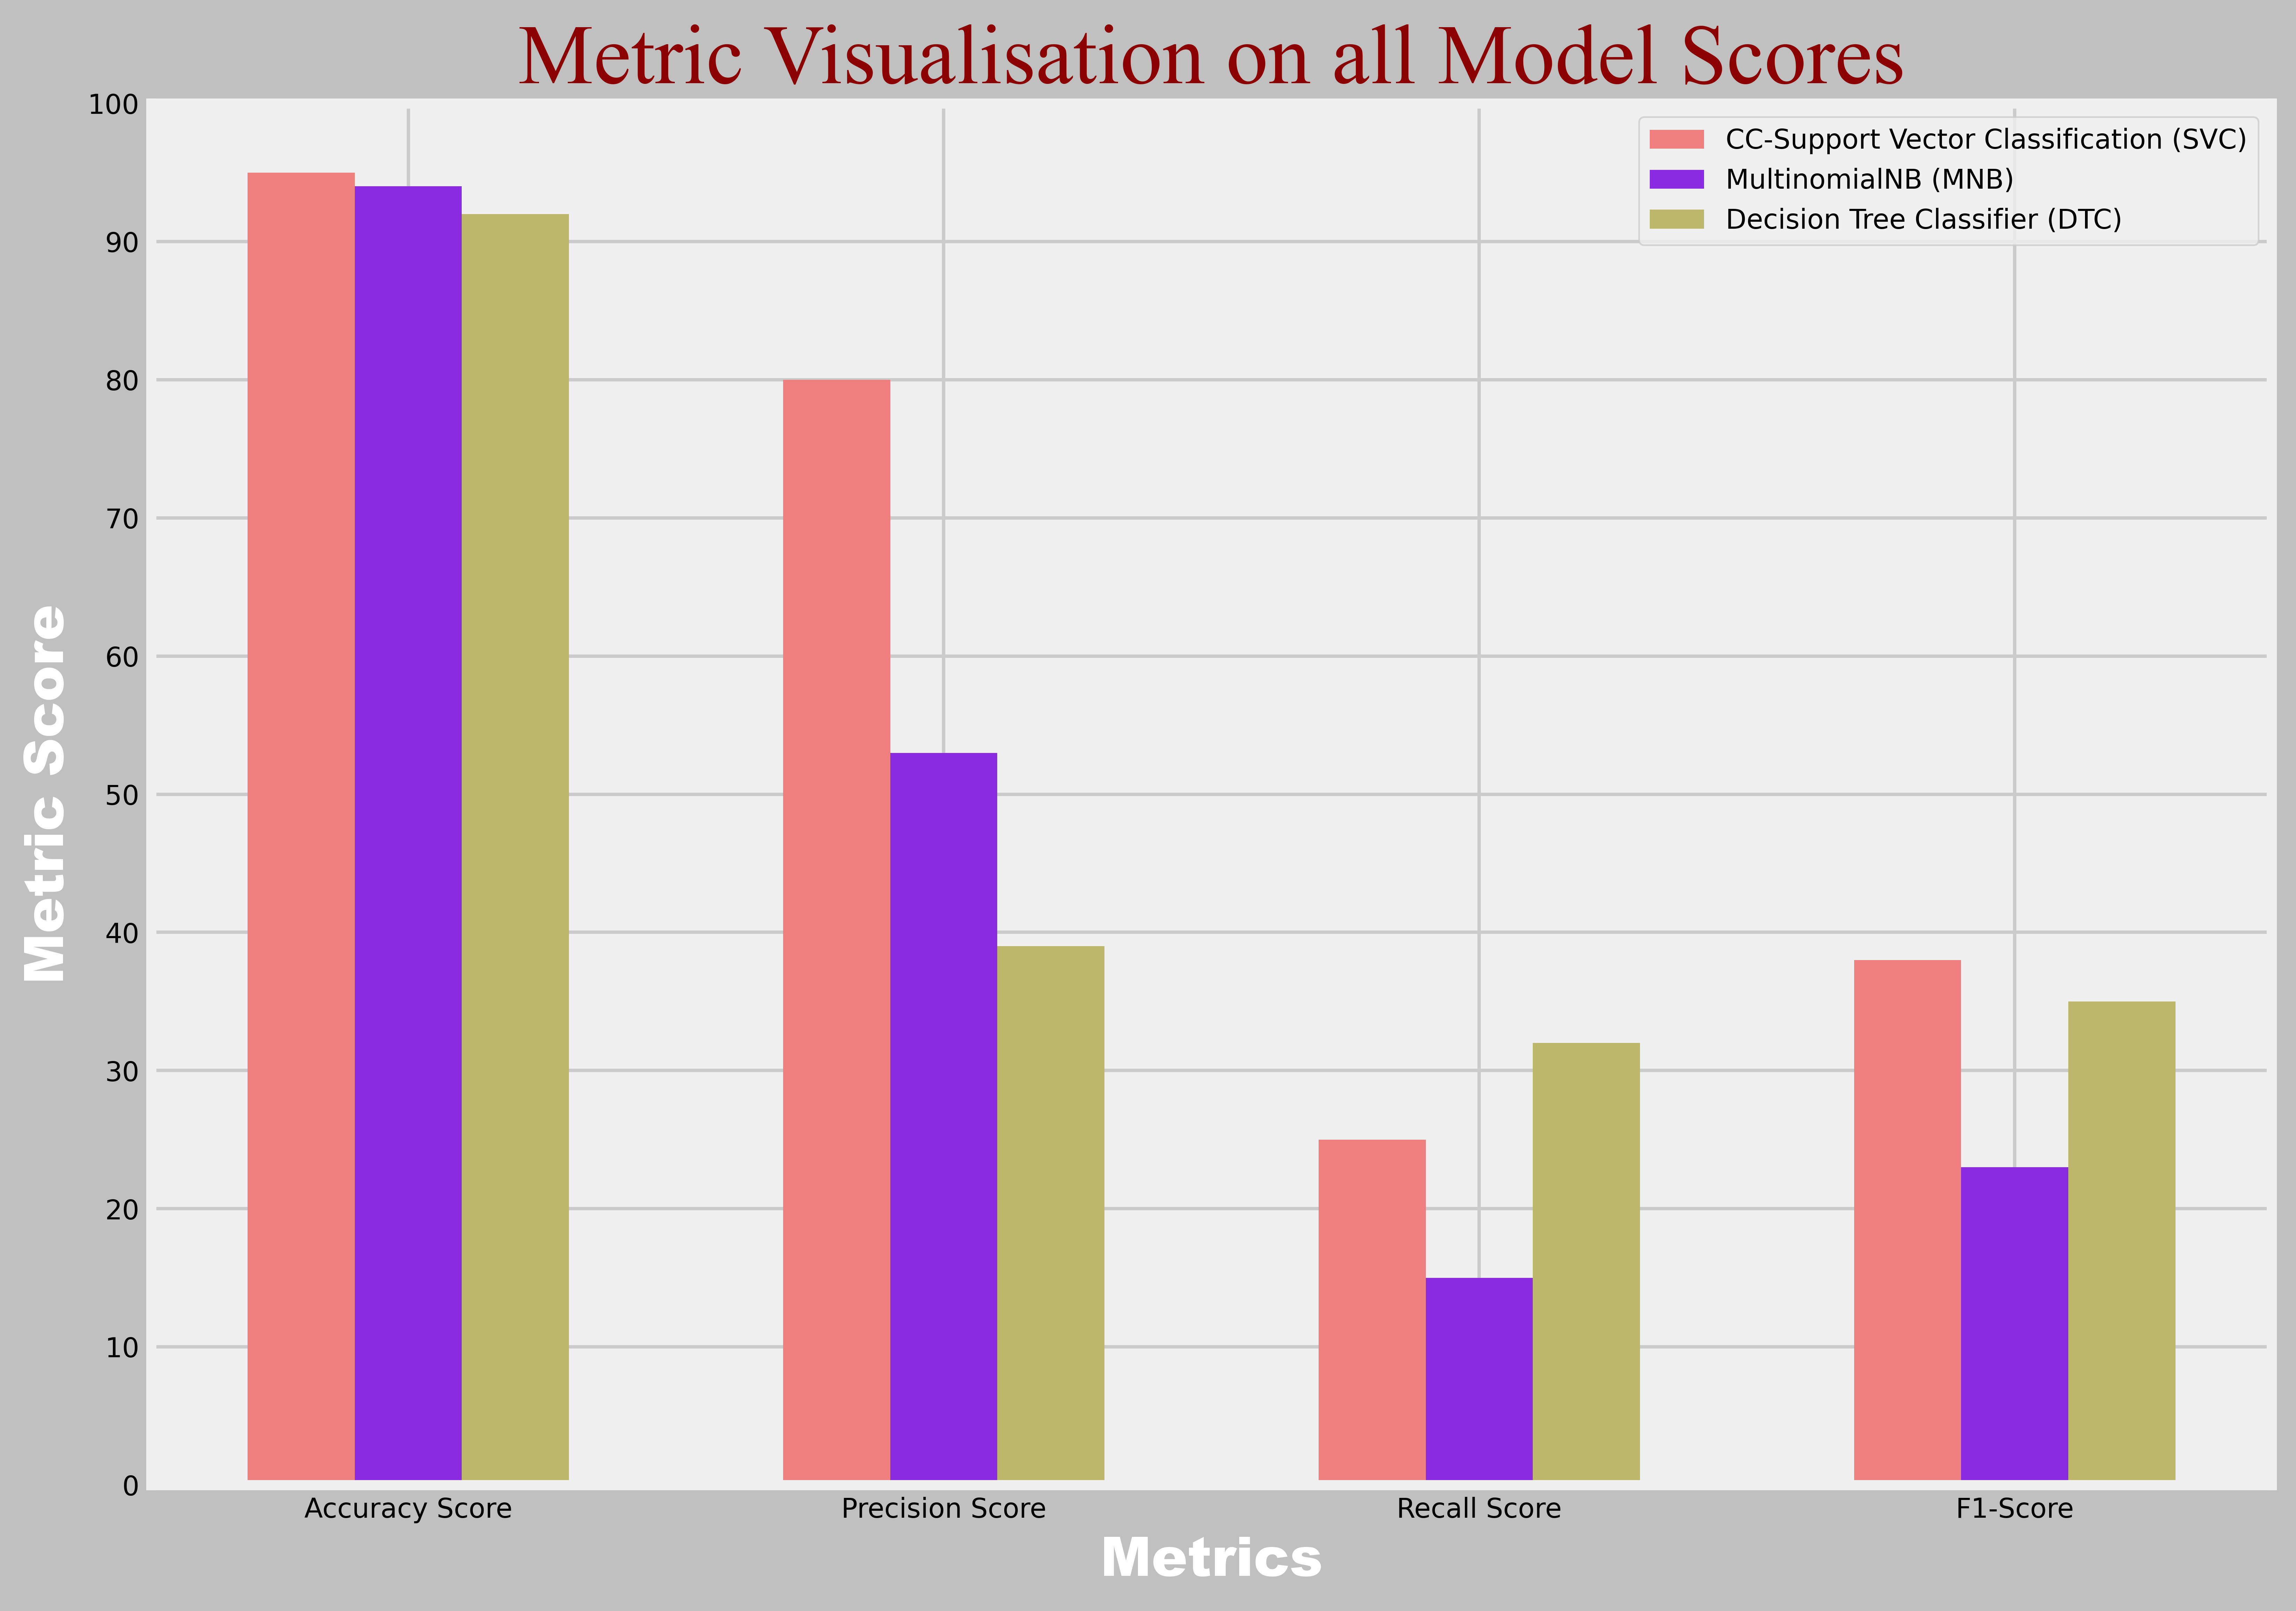

End of the Workshop 02.


In [80]:
svc_scores=(
    int(svc_accuracy_score*100),
    int(svc_precision_score*100),
    int(svc_recall_score*100),
    int(svc_f1_score*100)
)

mnb_scores=(
    int(mnb_accuracy_score*100),
    int(mnb_precision_score*100),
    int(mnb_recall_score*100),
    int(mnb_f1_score*100)
)

dtc_scores = (
    int(dtc_accuracy_score * 100), 
    int(dtc_precision_score * 100), 
    int(dtc_recall_score * 100), 
    int(dtc_f1_score * 100)
)

x_grid=["Accuracy Score","Precision Score","Recall Score","F1-Score"]
y_grid=[value for value in range(0,105,10)]
xpos=np.arange(len(x_grid))
bar_width=.2

style.use("fivethirtyeight")
plt.rcParams['font.size']=8
plt.figure(figsize=(10,7),dpi=700,facecolor="silver")
plt.title(
    "Metric Visualisation on all Model Scores",
    fontdict={
        "fontname": "Times New Roman", 
        "fontsize": 25
    },
    color="darkred"
)
plt.bar(xpos,svc_scores,width=bar_width, color="lightcoral",label="CC-Support Vector Classification (SVC)")
plt.bar((xpos + 0.2), mnb_scores, width=bar_width, color="blueviolet", label="MultinomialNB (MNB)")
plt.bar((xpos + 0.4), dtc_scores, width=bar_width, color="darkkhaki", label="Decision Tree Classifier (DTC)")
plt.xlabel(  
    "Metrics", 
    fontdict={
        "fontname": "Arial Black", 
        "fontsize": 16
    }, 
    color="white"
)
plt.xticks((xpos+0.2),x_grid)
plt.ylabel(  
    "Metric Score", 
    fontdict={
        "fontname": "Arial Black", 
        "fontsize": 16
    }, 
    color="white"
)

plt.yticks(y_grid)
plt.legend()
plt.savefig("Workshop 2 - Graph.jpg", dpi=700)
plt.show()

print("End of the Workshop 02.")


# Data Preprocessing 

In [92]:
def preprocess(dataframe):
    messages=dataframe.translate(str.maketrans('','',string.punctuation))
    messages=[word for word in messages.split() if word.lower() not in stopwords.words("english")]
    spam_words=''

    #print(messages)

    for messages in messages:
        stemmer=SnowballStemmer("english")
        spam_words+=(stemmer.stem(messages))+" "

    return spam_words

formspring_df_text_features=df['text'].copy()
formspring_df_text_features=formspring_df_text_features.apply(preprocess)
formspring_df_features=tfid_vectorizer.fit_transform(formspring_df_text_features)
    

# Applying Vectorizer to Texts

In [96]:
print("Text features from the 'Pre-Precessed Dataset - Formspring.csv':")
print('-'*73)
print(formspring_df_text_features)

Text features from the 'Pre-Precessed Dataset - Formspring.csv':
-------------------------------------------------------------------------
0        q what039 favorit song dbra like mani song fav...
1                                     q 3bra 3 haha jk 33 
2        q quothey angel duh sexyquotbra realli thank h...
3                                                   q bra 
4                                        q meowwwbra rawr 
                               ...                        
13142    q your parti friend drove drunk won039t give k...
13143    q youu2019r awesom give compliment deserv itbr...
13144              q yu play yurself bra time sometim day 
13145    q yukk beer disgust drink i039m alreadi drunk ...
13146    q told u den would make less funbra would make...
Name: text, Length: 13147, dtype: object


# Testing and Training DataFrame

In [99]:
df_text_features=pd.DataFrame(formspring_df_text_features)
df_text_features.to_csv("My Formspring Features.csv")
df_features_train,df_features_test,df_labels_train,df_labels_test=train_test_split(
    formspring_df_features,
    df["answer"],
    test_size=0.3,
    random_state=4861,
)

In [103]:
print("DataFrame Features Train:")
print('-'*43)
print(df_features_train)

DataFrame Features Train:
-------------------------------------------
  (0, 10229)	0.14310523247165424
  (0, 10893)	0.12725038277530326
  (0, 13848)	0.47038633677995534
  (0, 9221)	0.13762449185687312
  (0, 17686)	0.3076007061604975
  (0, 17079)	0.19988031198368786
  (0, 14264)	0.30423069647233597
  (0, 13932)	0.3951506947242088
  (0, 13931)	0.41222184814032115
  (0, 2254)	0.41222184814032115
  (1, 19077)	0.2684156241499941
  (1, 7531)	0.25466559294788454
  (1, 15830)	0.251295184233225
  (1, 17116)	0.284844928819744
  (1, 19307)	0.4620985009841858
  (1, 9866)	0.3581362839938149
  (1, 20422)	0.3560996909448268
  (1, 12439)	0.5002089293203439
  (2, 14209)	0.2661303158747281
  (2, 8629)	0.39985632187982456
  (2, 14921)	0.3103843757926528
  (2, 8745)	0.5923908460415378
  (2, 3969)	0.34266094394485197
  (2, 19125)	0.4523358034800861
  (3, 10698)	0.1671329009355508
  :	:
  (9200, 3773)	0.6146840900575767
  (9200, 6481)	0.17670987963773327
  (9200, 19530)	0.26796169541363735
  (9200, 14077)	0

In [105]:
print("Dataframe Features Test:")
print('-' * 53)
print(df_features_test)

Dataframe Features Test:
-----------------------------------------------------
  (0, 12657)	0.3897325957124355
  (0, 921)	0.49551572096007723
  (0, 18950)	0.7762555469178058
  (1, 11033)	0.13383193340180494
  (1, 20096)	0.20661306796957477
  (1, 13545)	0.1499597879908353
  (1, 16815)	0.2384797954820774
  (1, 4286)	0.16650777332889422
  (1, 12827)	0.2595268494870091
  (1, 6807)	0.2797984156292766
  (1, 10991)	0.26395664929925233
  (1, 16327)	0.26395664929925233
  (1, 9224)	0.25372926880189156
  (1, 4057)	0.3077025521805435
  (1, 15714)	0.3421640897814075
  (1, 13380)	0.36823323660879254
  (1, 18882)	0.36823323660879254
  (2, 2831)	0.19472932972196022
  (2, 9221)	0.20594543884152852
  (2, 7425)	0.22914949024941608
  (2, 20364)	0.30075417354484674
  (2, 1936)	0.2914607460030977
  (2, 12952)	0.32640435934548906
  (2, 5605)	0.5220988101545037
  (2, 8477)	0.5591315254526662
  :	:
  (3942, 8505)	0.18543951247983004
  (3942, 16904)	0.2358838697370509
  (3942, 1055)	0.24517361669492926
  (3942,

In [107]:
print("Dataframe Labels Train:")
print('-' * 27)
print(df_labels_train)

Dataframe Labels Train:
---------------------------
5634     0
3350     0
8939     0
5109     0
1001     0
        ..
4125     0
9563     0
9813     0
12745    0
2101     0
Name: answer, Length: 9202, dtype: int64


In [109]:
print("Dataframe Labels Test:")
print('-' * 27)
print(df_labels_test)

Dataframe Labels Test:
---------------------------
623      0
9971     0
10347    0
8597     0
3371     0
        ..
7440     0
9434     0
2928     0
7176     0
7887     0
Name: answer, Length: 3945, dtype: int64
